In [1]:
from google.colab import files
uploaded = files.upload()


Saving Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv to Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv


In [2]:
import pandas as pd

zhvi = pd.read_csv('Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,211260.036103,...,503615.315072,504041.821563,503718.362554,502808.007227,501009.557989,498808.457699,496204.055384,494124.281431,493001.330687,493204.183103
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,117013.178176,...,546231.311054,546796.399030,548762.235908,551106.382435,554471.978686,557358.140113,559986.738688,561842.069988,563135.564098,565788.741081
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,103949.915049,...,280364.214678,279752.347810,279127.333004,278293.728257,277333.261939,276527.656740,275525.866223,274583.243231,273646.325157,272866.097556
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,174013.827521,...,534715.303771,532223.576798,532092.170856,531746.686451,531633.596410,532026.401149,534097.682017,536855.532134,538527.597608,539769.173343
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,102741.047530,...,273881.498841,273638.371800,273235.446503,272375.802036,271334.625636,270440.150302,269437.236297,268523.691827,267647.045438,266768.667034


Separate date cols from other info cols:

In [4]:
import numpy as np

date_cols = []
id_cols = []
for col in zhvi.columns:
    try:
        pd.to_datetime(col)  # works only for date-like column names (e.g., '2015-01-31')
        date_cols.append(col)
    except Exception:
        id_cols.append(col)

print("ID columns (first few):", id_cols[:10])
print("Date columns (first few):", date_cols[:5], "… total:", len(date_cols))


ID columns (first few): ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
Date columns (first few): ['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31'] … total: 309


We need to "pivot_longer" in pandas, ie melt:  

In [5]:
zhvi_long = zhvi.melt(
    id_vars=id_cols,           # keep all non-date columns during melt
    value_vars=date_cols,      # stack all date columns
    var_name='date',
    value_name='zhvi'
)

Keep what we need to merge:

In [6]:
keep_cols = ['RegionName', 'StateName', 'date', 'zhvi']
zhvi_long = zhvi_long[keep_cols].copy()

Standardize ZIP and month:

In [7]:
zhvi_long['ZIP'] = zhvi_long['RegionName'].astype(str).str.zfill(5) #make sure ZIP is good
zhvi_long['month'] = pd.to_datetime(zhvi_long['date'], errors='coerce').dt.to_period('M') #make sure month is good

Keep only info from Arizona (filter):

In [8]:
zhvi_long = zhvi_long[zhvi_long['StateName'] == 'AZ']

Final column check:

In [10]:
zhvi_long = zhvi_long[['ZIP', 'month', 'zhvi']].sort_values(['ZIP', 'month'])
zhvi_long.head(10)

,ZIP,month,zhvi
10717,85003,2000-01,140453.631634
37027,85003,2000-02,141061.251067
63337,85003,2000-03,141910.157414
89647,85003,2000-04,143845.258656
115957,85003,2000-05,145868.175082
142267,85003,2000-06,147225.703337
168577,85003,2000-07,147914.301623
194887,85003,2000-08,148460.684066
221197,85003,2000-09,149552.060738
247507,85003,2000-10,150743.299075


In [11]:
zhvi_long.shape

(92700, 3)

I only need dates that correspond with my crime data:

In [14]:
zhvi_long = zhvi_long[
    (zhvi_long['month'] >= '2015-11')
    & (zhvi_long['month'] <= '2017-11')
].reset_index(drop=True)
zhvi_long['month'].unique()

<PeriodArray>
['2015-11', '2015-12', '2016-01', '2016-02', '2016-03', '2016-04', '2016-05',
 '2016-06', '2016-07', '2016-08', '2016-09', '2016-10', '2016-11', '2016-12',
 '2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07',
 '2017-08', '2017-09', '2017-10', '2017-11']
Length: 25, dtype: period[M]

In [16]:
zhvi_long.head()

,ZIP,month,zhvi
0,85003,2015-11,322335.681342
1,85003,2015-12,324289.155227
2,85003,2016-01,327547.904653
3,85003,2016-02,331011.290054
4,85003,2016-03,333443.717522


In [17]:
zhvi_long.shape

(7500, 3)

Now I'm ready to upload cleaned dataset from Module 3 Basics:

In [19]:
from google.colab import files
uploaded = files.upload()

Saving crime_clean.csv to crime_clean.csv


In [21]:
crime_month_zip = (
    df.groupby(['ZIP', 'month'])
      .size()
      .reset_index(name='crime_count')
)


In [22]:
crime_month_zip.head()

,ZIP,month,crime_count
0,85003,2015-11,69
1,85003,2015-12,65
2,85003,2016-01,61
3,85003,2016-02,56
4,85003,2016-03,41


In [23]:
crime_month_zip.shape

(1500, 3)

Looks good.  I'll merge the crime and housing data:

In [26]:
# Convert 'ZIP' column to string in both dataframes
crime_month_zip['ZIP'] = crime_month_zip['ZIP'].astype(str)
zhvi_long['ZIP'] = zhvi_long['ZIP'].astype(str)

# Convert 'month' column to Period[M] in crime_month_zip
crime_month_zip['month'] = pd.to_datetime(crime_month_zip['month']).dt.to_period('M')

merged = crime_month_zip.merge(
    zhvi_long,
    on=['ZIP', 'month'],
    how='left'
)

In [27]:
merged.head()

,ZIP,month,crime_count,zhvi
0,85003,2015-11,69,322335.681342
1,85003,2015-12,65,324289.155227
2,85003,2016-01,61,327547.904653
3,85003,2016-02,56,331011.290054
4,85003,2016-03,41,333443.717522


In [28]:
merged.shape

(1500, 4)

In [29]:
merged.info()
merged[['crime_count','zhvi']].describe()
merged.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   ZIP          1500 non-null   object   
 1   month        1500 non-null   period[M]
 2   crime_count  1500 non-null   int64    
 3   zhvi         1499 non-null   float64  
dtypes: float64(1), int64(1), object(1), period[M](1)
memory usage: 47.0+ KB


,0
ZIP,0
month,0
crime_count,0
zhvi,1


Need to get rid of 1 missing value in zhvi

In [30]:
merged[merged['zhvi'].isna()]

,ZIP,month,crime_count,zhvi
1221,85290,2016-07,1,NaN


In [31]:
merged = merged.dropna(subset=['zhvi']).reset_index(drop=True)


In [32]:
merged.isna().sum()
merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   ZIP          1499 non-null   object   
 1   month        1499 non-null   period[M]
 2   crime_count  1499 non-null   int64    
 3   zhvi         1499 non-null   float64  
dtypes: float64(1), int64(1), object(1), period[M](1)
memory usage: 47.0+ KB


Scatterplot (crime vs home value)

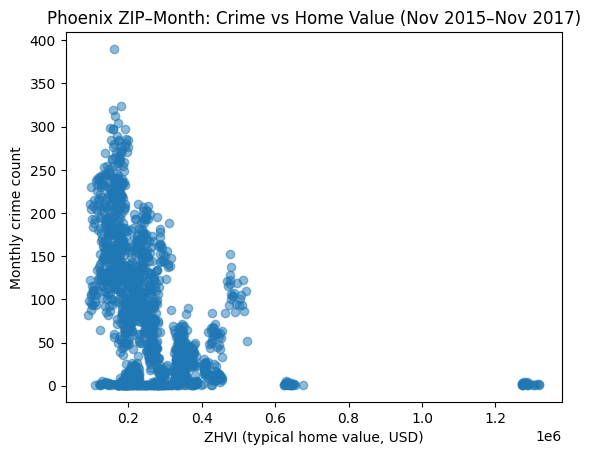

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(merged['zhvi'], merged['crime_count'], alpha=0.5)
plt.xlabel('ZHVI (typical home value, USD)')
plt.ylabel('Monthly crime count')
plt.title('Phoenix ZIP–Month: Crime vs Home Value (Nov 2015–Nov 2017)')
plt.show()


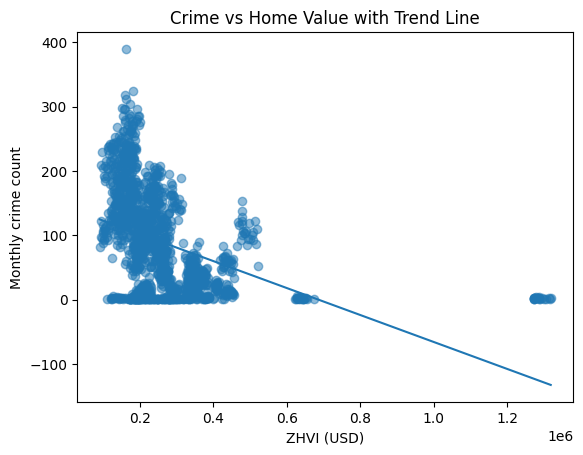

In [34]:
import numpy as np

x = merged['zhvi'].values
y = merged['crime_count'].values
m, b = np.polyfit(x, y, 1)
plt.figure()
plt.scatter(x, y, alpha=0.5)
plt.plot(np.sort(x), m*np.sort(x) + b)  # line of best fit
plt.xlabel('ZHVI (USD)')
plt.ylabel('Monthly crime count')
plt.title('Crime vs Home Value with Trend Line')
plt.show()


<Axes: xlabel='ZIP', ylabel='Avg monthly crime'>

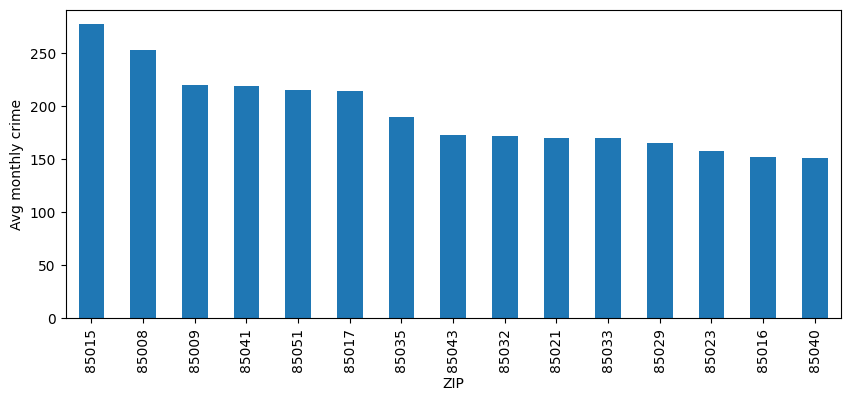

In [35]:
avg_by_zip = (
    merged.groupby('ZIP')['crime_count']
          .mean()
          .sort_values(ascending=False)
          .head(15)
)

avg_by_zip.plot(kind='bar', figsize=(10,4), xlabel='ZIP', ylabel='Avg monthly crime')


<Axes: xlabel='ZIP', ylabel='Avg ZHVI (USD)'>

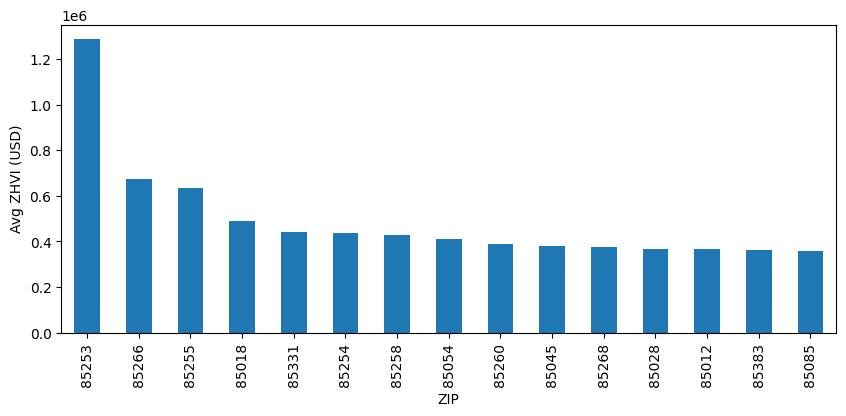

In [36]:
avg_zhvi_by_zip = merged.groupby('ZIP')['zhvi'].mean().sort_values(ascending=False).head(15)
avg_zhvi_by_zip.plot(kind='bar', figsize=(10,4), xlabel='ZIP', ylabel='Avg ZHVI (USD)')


In [37]:
import statsmodels.api as sm

X = sm.add_constant(merged['zhvi'])   # intercept + zhvi
y = merged['crime_count']
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            crime_count   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     339.8
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           1.52e-68
Time:                        22:00:57   Log-Likelihood:                -8484.9
No. Observations:                1499   AIC:                         1.697e+04
Df Residuals:                    1497   BIC:                         1.698e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        143.8268      3.539     40.646      0.0

In [38]:
merged_out = merged.copy()
# make month a string for CSV readability
merged_out['month'] = merged_out['month'].astype(str)
merged_out.to_csv('phoenix_crime_housing_2015_2017.csv', index=False)


In [39]:
from google.colab import files
files.download('phoenix_crime_housing_2015_2017.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>